In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
import xgboost as xgb 
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from src.balance import split_data_nested_cv_ts, split_data, drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, ensemble_sample_and_merge

In [2]:
SEED = 42
TOP_FEATURES = 10

In [3]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES, all_features=False)
dataclass.read()
# df = dataclass.preprocess()  # Assume this keeps mouse IDs for splitting
# df.to_csv('preprocessed.csv', index=False)

df = dataclass.df

# Hyperparameter grid for XGBClassifier
param_grid = {
    'xgbclassifier__n_estimators': [100, 500, 1000],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__subsample': [0.7, 0.8, 1.0]
}

def expanding_window_split(df, n_splits=4):
    """
    Perform Expanding Window Split

    Args:
        df (pd.DataFrame): DataFrame containing all instances, sorted by time.
        n_splits (int): Number of splits for expanding windows.

    Returns:
        splits (dict): Dictionary with train-test-validation splits for each fold.
    """
    splits = {}

    # Sort the DataFrame by 'day_of_study' to ensure chronological order
    df = df.sort_values(by='day_of_study').reset_index(drop=True)

    # TimeSeriesSplit for expanding window
    tscv = TimeSeriesSplit(n_splits=n_splits)
    for i, (train_indices, test_indices) in enumerate(tscv.split(df)):
        
        # Prepare training, validation, and testing sets
        X_train = df.iloc[train_indices].drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_train = df.iloc[train_indices]['group_name'].reset_index(drop=True)

        # Test data
        X_test = df.iloc[test_indices].drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_test = df.iloc[test_indices]['group_name'].reset_index(drop=True)

        # Store splits
        splits[i] = {
            'X_train': X_train,
            'y_train': y_train,
            'X_test': X_test,
            'y_test': y_test
        }
    
    return splits

# Apply expanding window split with oversampling
m_data = expanding_window_split(df)



Fold 0:
Original train class distribution: Counter({0: 64, 1: 14})
Original test class distribution: Counter({0: 61, 1: 15})
Best parameters for fold 0: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.8}

Fold 0 results:
Accuracy: 0.8158
F1-macro: 0.5589
F1-micro: 0.8158
F1-weighted: 0.7626
Precision: 0.6667
Recall: 0.1333
ROC AUC: 0.7016
True Positives: 2, False Negatives: 13, False Positives: 1, True Negatives: 60


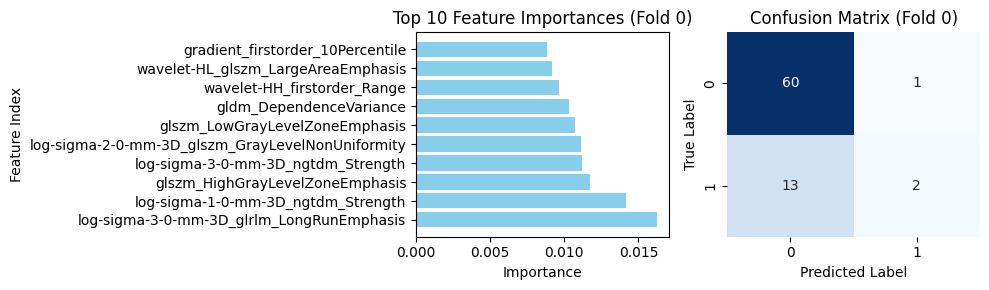


Fold 1:
Original train class distribution: Counter({0: 125, 1: 29})
Original test class distribution: Counter({0: 58, 1: 18})
Best parameters for fold 1: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 1 results:
Accuracy: 0.8158
F1-macro: 0.7697
F1-micro: 0.8158
F1-weighted: 0.8239
Precision: 0.5833
Recall: 0.7778
ROC AUC: 0.7950
True Positives: 14, False Negatives: 4, False Positives: 10, True Negatives: 48


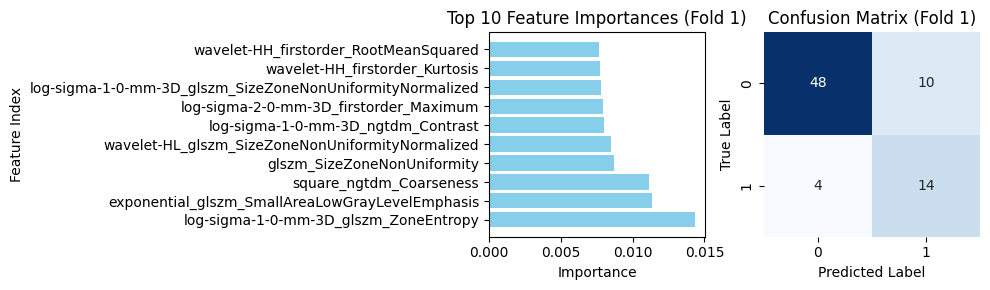


Fold 2:
Original train class distribution: Counter({0: 183, 1: 47})
Original test class distribution: Counter({0: 61, 1: 15})
Best parameters for fold 2: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 2 results:
Accuracy: 0.6842
F1-macro: 0.5789
F1-micro: 0.6842
F1-weighted: 0.7064
Precision: 0.3043
Recall: 0.4667
ROC AUC: 0.6579
True Positives: 7, False Negatives: 8, False Positives: 16, True Negatives: 45


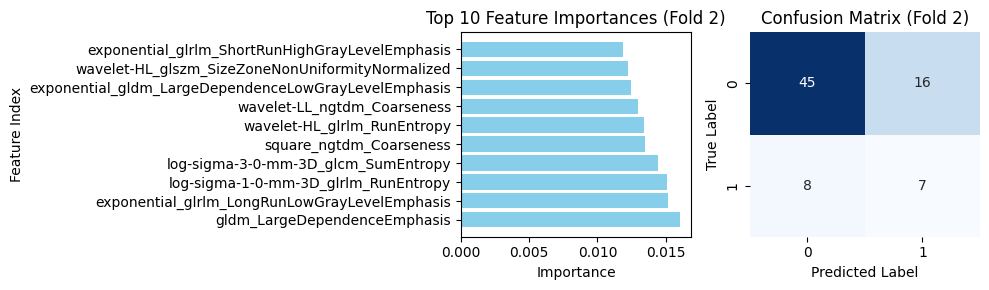


Fold 3:
Original train class distribution: Counter({0: 244, 1: 62})
Original test class distribution: Counter({0: 72, 1: 4})
Best parameters for fold 3: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.7}

Fold 3 results:
Accuracy: 0.9474
F1-macro: 0.7361
F1-micro: 0.9474
F1-weighted: 0.9474
Precision: 0.5000
Recall: 0.5000
ROC AUC: 0.9757
True Positives: 2, False Negatives: 2, False Positives: 2, True Negatives: 70


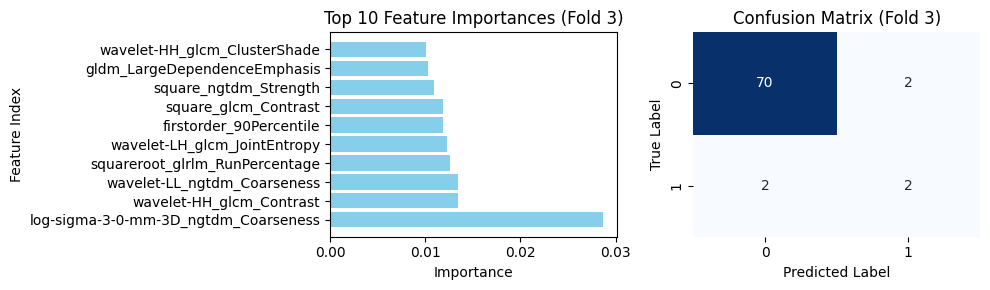


All Folds Completed.

--------------------------------------------------

Summary of Results:

[array([0.        , 0.00093852, 0.00248741, ..., 0.        , 0.        ,
       0.        ], dtype=float32), array([0.00334883, 0.0007896 , 0.00069675, ..., 0.        , 0.        ,
       0.        ], dtype=float32), array([0.00555646, 0.        , 0.        , ..., 0.        , 0.        ,
       0.        ], dtype=float32), array([0.00425013, 0.        , 0.01186336, ..., 0.        , 0.0031265 ,
       0.        ], dtype=float32)]


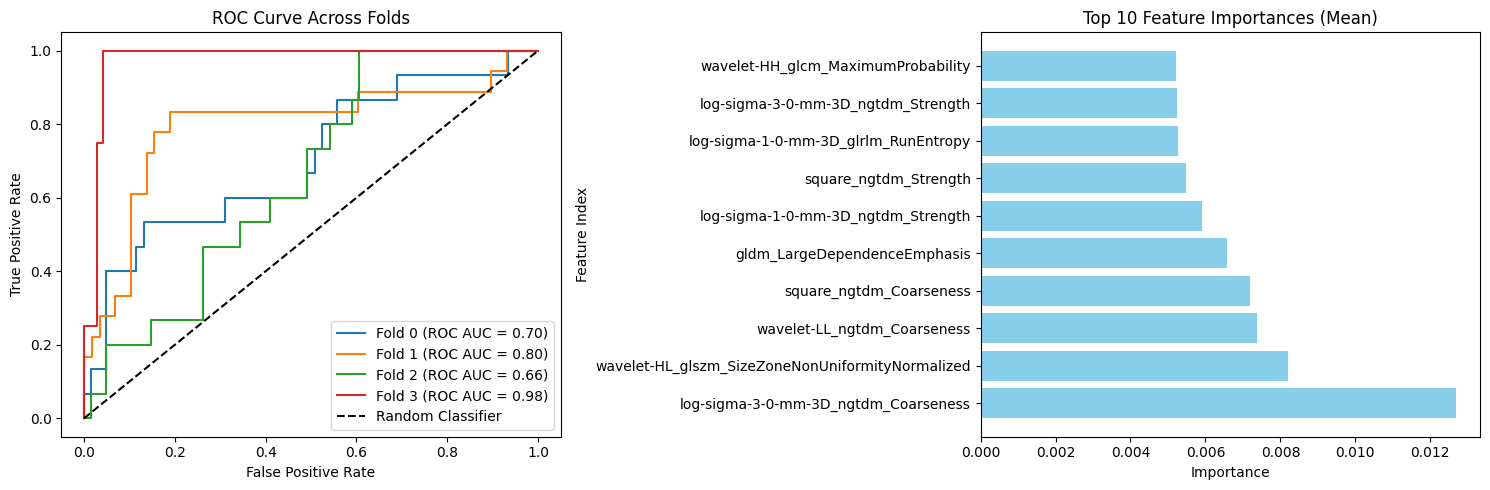


Summary Across Folds:
Mean accuracy: 0.8158
Mean F1-macro: 0.6609
Mean F1-micro: 0.8158
Mean F1-weighted: 0.8101
Mean precision: 0.5136
Mean recall: 0.4694
Mean ROC AUC: 0.7826


In [5]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler

# Track results for each fold
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_pr_aucs, fold_f1_micros, fold_f1_weighted, feature_importances = [], [], [], [], [], [], [], [], []
class_metrics = {'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Store ROC and PR curve points for all folds
roc_curves = []
pr_curves = []

split_0_data = next(iter(m_data.values()))
# print(split_0_data['X_train'].columns)

feature_names = split_0_data['X_train'].columns  # This will be a pandas.Index
feature_names = feature_names.str.replace('original_', '', regex=False)

for fold, split_data in m_data.items():
    print(f"\nFold {fold}:")
    print(f"Original train class distribution: {Counter(split_data['y_train'])}")
    print(f"Original test class distribution: {Counter(split_data['y_test'])}")

    model = Pipeline([
            ('scaler', StandardScaler()),
            
        
        ('smote', SMOTE(random_state=SEED)),
        ('xgbclassifier', xgb.XGBClassifier(random_state=SEED)),
    ])

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(split_data['X_train'], split_data['y_train'])

    best_model = grid_search.best_estimator_
    print(f"Best parameters for fold {fold}: {grid_search.best_params_}")

    # Extract feature importances from XGBoost
    xgb_model = best_model.named_steps['xgbclassifier']
    importances = xgb_model.feature_importances_

    # Evaluate on the test set
    preds = best_model.predict(split_data['X_test'])
    preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class
    
    # Calculate metrics
    accuracy = accuracy_score(split_data['y_test'], preds)
    f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    f1_micro = f1_score(split_data['y_test'], preds, average='micro')
    f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
    precision = precision_score(split_data['y_test'], preds)
    recall = recall_score(split_data['y_test'], preds)

    fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)

    # precision_c, recall_c, _ = precision_recall_curve(split_data['y_test'], preds_proba, pos_label=1)
    # pr_auc = average_precision_score(split_data['y_test'], preds_proba)
    
    roc_curves.append((fpr, tpr))
    # pr_curves.append((precision_c, recall_c))

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()

    # Print fold results
    print(f"\nFold {fold} results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"F1-micro: {f1_micro:.4f}")
    print(f"F1-weighted: {f1_weighted:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    # print(f"PR AUC: {pr_auc:.4f}")
    print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
    
    # Plot top k features for this fold
    top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
    top_importances = importances[top_indices]
    # print(top_importances)
    # print(top_indices)
    # print(feature_names[top_indices])

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
    plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
    plt.ylabel("Feature Index")
    plt.xlabel("Importance")
    plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
    # Plot confusion matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(split_data['y_test'], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix (Fold {fold})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # Track results
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_f1_micros.append(f1_micro)
    fold_f1_weighted.append(f1_weighted)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_roc_aucs.append(roc_auc)
    feature_importances.append(importances)
    # fold_pr_aucs.append(pr_auc)

    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

print(f"\nAll Folds Completed.")
print("\n--------------------------------------------------")
print("\nSummary of Results:\n")

# print(feature_importances)

# Plotting ROC and Precision-Recall curves side by side
plt.figure(figsize=(15, 5))

# ROC Curve Plot
plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
for i, (fpr, tpr) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.title("ROC Curve Across Folds")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

print(feature_importances)
# Calculate mean importances across folds
mean_importances = np.mean(feature_importances, axis=0)
# print(mean_importances)
# Get indices of the top k features by mean
top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
top_importances_mean = mean_importances[top_indices_mean]
# print(top_indices_mean)
# print(top_importances_mean)
# print(feature_names[top_indices_mean])

plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
plt.ylabel("Feature Index")
plt.xlabel("Importance")
plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

# Precision-Recall Curve Plot
# plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
# for i, (precision, recall) in enumerate(pr_curves):
#     plt.plot(recall, precision, label=f'Fold {i} (PR AUC = {fold_pr_aucs[i]:.2f})')
# plt.title("Precision-Recall Curve Across Folds")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.legend(loc="lower right")

# Display the plots side by side
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

# Display summary statistics across folds
print(f"\nSummary Across Folds:")
print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
print(f"Mean precision: {np.mean(fold_precisions):.4f}")
print(f"Mean recall: {np.mean(fold_recalls):.4f}")
print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")
# print(f"Mean PR AUC: {np.mean(fold_pr_aucs):.4f}")